# Retail Sales Analysis

This notebook explores retail sales performance using Python. It prepares the dataset, calculates key performance indicators, performs exploratory data analysis (EDA), and exports selected charts for the portfolio project page.

**Project focus**
- Revenue and profit performance
- Product and category performance
- Customer segment contribution
- Regional performance
- Monthly revenue trend



## 1. Import Libraries and Set Paths



In [32]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../dataset/Sample - Superstore.csv")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Load and Prepare Data

This step loads the retail dataset, converts date columns into datetime format, and creates a monthly field for trend analysis.

In [33]:
df = pd.read_csv(DATA_PATH, encoding="latin1")

# Convert date columns to datetime format.
date_columns = ["Order Date", "Ship Date"]
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# Create a month column for time-series analysis.
df["Month"] = df["Order Date"].dt.to_period("M")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9994, 22)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10


## 3. Data Quality Check

Before analysis, the dataset is checked for missing values, duplicate rows, and data types.

In [34]:
print("Data information:")
df.info()

print("Missing values by column:")
display(df.isnull().sum())

print("Duplicated rows:", df.duplicated().sum())

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Month            0
dtype: int64

Duplicated rows: 0


## 4. Helper Functions

Reusable functions are created to keep the analysis cleaner and easier to maintain.

In [35]:
def make_kpi_summary(data):
    """Calculate high-level business KPIs."""
    return pd.Series({
        "Total Revenue": data["Sales"].sum(),
        "Total Profit": data["Profit"].sum(),
        "Total Orders": data["Order ID"].nunique(),
        "Total Customers": data["Customer ID"].nunique()
    })


def group_sum(data, group_col, value_cols, sort_by=None, ascending=False, top_n=None):
    """Group data, calculate sums, sort results, and optionally return top N rows."""
    result = data.groupby(group_col)[value_cols].sum()

    if sort_by is None:
        sort_by = value_cols[0] if isinstance(value_cols, list) else value_cols

    result = result.sort_values(
        by=sort_by,
        ascending=ascending
    ) if isinstance(result, pd.DataFrame) else result.sort_values(ascending=ascending)

    if top_n:
        result = result.head(top_n)

    return result


def save_current_figure(filename):
    """Save the active matplotlib figure into the figures folder."""
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

## 5. KPI Summary

These KPIs provide a quick overview of the overall retail sales performance.

In [36]:
kpi_summary = make_kpi_summary(df)

kpi_summary_formatted = pd.Series({
    "Total Revenue": f"${kpi_summary['Total Revenue']:,.2f}",
    "Total Profit": f"${kpi_summary['Total Profit']:,.2f}",
    "Total Orders": f"{int(kpi_summary['Total Orders']):,}",
    "Total Customers": f"{int(kpi_summary['Total Customers']):,}"
})

kpi_summary_formatted

Total Revenue      $2,297,200.86
Total Profit         $286,397.02
Total Orders               5,009
Total Customers              793
dtype: object

## 6. Python EDA Chart 1 - Monthly Revenue Trend

This chart shows how revenue changes over time. The month values are sorted chronologically to avoid misleading trend interpretation.

**Portfolio export:** `retail_monthly_revenue_trend.png`

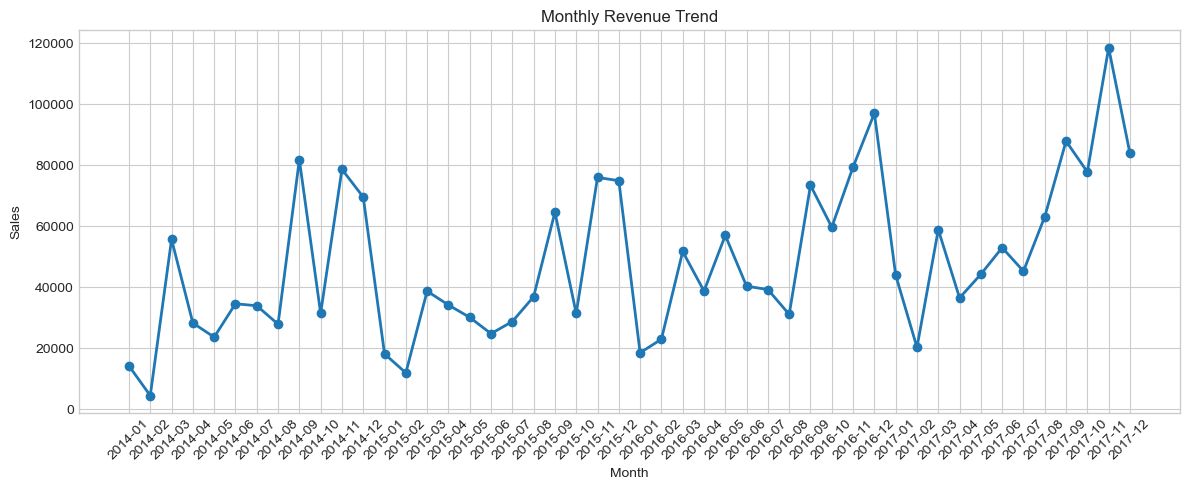

In [37]:
monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
    .sort_index()
)

monthly_sales_plot = monthly_sales.copy()
monthly_sales_plot.index = monthly_sales_plot.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales_plot.index, monthly_sales_plot.values, marker="o", linewidth=2)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
save_current_figure("retail_monthly_revenue_trend.png")

## 7. Python EDA Chart 2 - Top Products by Revenue

This chart identifies the products that generated the highest revenue.

**Portfolio export:** `retail_top_products_by_revenue.png`

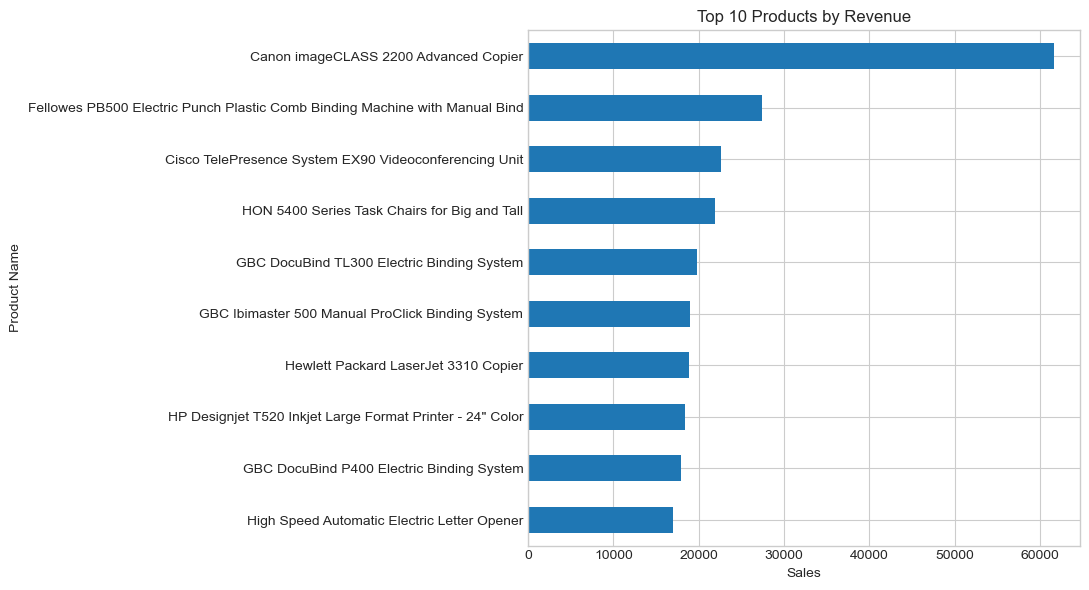

In [38]:
top_products = group_sum(
    data=df,
    group_col="Product Name",
    value_cols="Sales",
    ascending=False,
    top_n=10
)

plt.figure(figsize=(11, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Sales")
plt.ylabel("Product Name")
save_current_figure("retail_top_products_by_revenue.png")

## 8. Python EDA Chart 3 - Profit by Category

This chart compares profit contribution across product categories.

**Portfolio export:** `retail_profit_by_category.png`

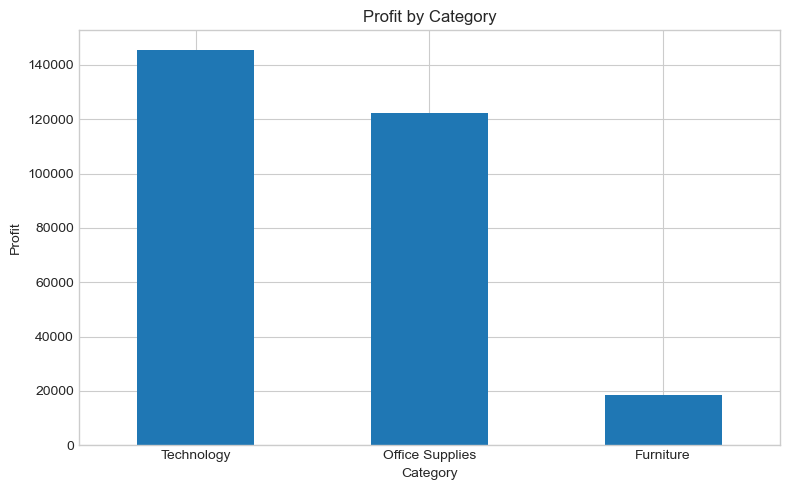

In [39]:
category_profit = group_sum(
    data=df,
    group_col="Category",
    value_cols="Profit",
    ascending=False
)

plt.figure(figsize=(8, 5))
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
save_current_figure("retail_profit_by_category.png")

## 9. Python EDA Chart 4 - Regional Performance

This chart compares sales and profit by region to understand geographical performance differences.

**Portfolio export:** `retail_region_performance.png`

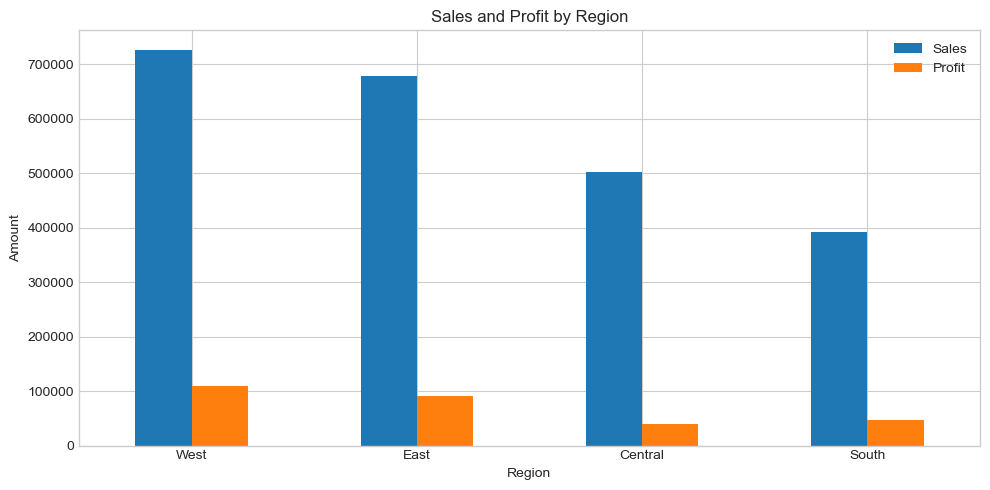

In [40]:
region_performance = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Sales", ascending=False)
)

region_performance.plot(kind="bar", figsize=(10, 5))
plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
save_current_figure("retail_region_performance.png")

## 10. Optional EDA - Customer Segment Performance

This chart is optional for the portfolio. Use it only if you want to show customer segment analysis in addition to the four main EDA charts.

**Optional export:** `retail_segment_performance.png`

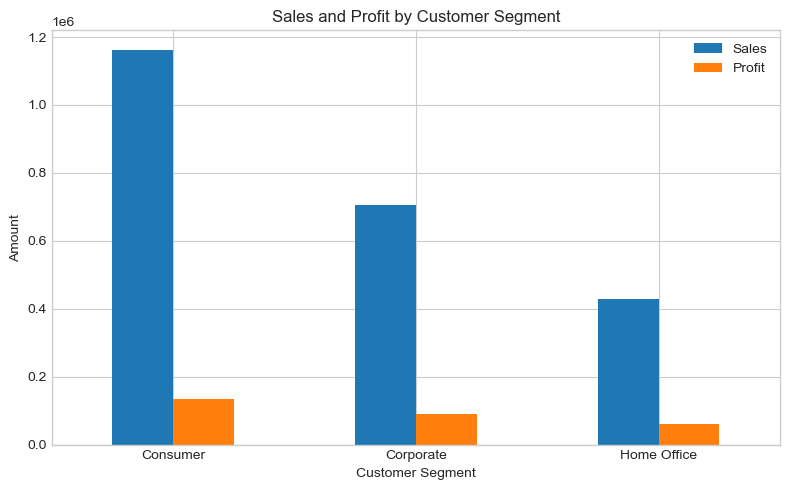

In [41]:
segment_performance = (
    df.groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Sales", ascending=False)
)

segment_performance.plot(kind="bar", figsize=(8, 5))
plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
save_current_figure("retail_segment_performance.png")

## 11. Key Findings

The following summary highlights the main findings from the retail sales analysis.

In [42]:
print("Total Revenue:", f"${kpi_summary['Total Revenue']:,.2f}")
print("Total Profit:", f"${kpi_summary['Total Profit']:,.2f}")
print("Total Orders:", f"{int(kpi_summary['Total Orders']):,}")
print("Total Customers:", f"{int(kpi_summary['Total Customers']):,}")

print("Top product by revenue:", top_products.index[0])
print("Most profitable category:", category_profit.index[0])
print("Highest sales region:", region_performance.index[0])
print("Largest customer segment:", segment_performance.index[0])

Total Revenue: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Top product by revenue: Canon imageCLASS 2200 Advanced Copier
Most profitable category: Technology
Highest sales region: West
Largest customer segment: Consumer
